## Imports

In [1]:
import sklearn
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib as mpl
import scipy.io as sio

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from scipy.io import loadmat
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import r2_score

import sys
sys.path.insert(1, '../SCA')
sys.path.insert(2, '../data')
from architecture import SCA_autoencoder
from model import SCA
from util import loss_func,create_W

In [2]:
monkeyC_cycling = loadmat('../data/monkeyC_cycling.mat')
data_array = monkeyC_cycling['data']
data_mask = monkeyC_cycling['mask']
data_func = monkeyC_cycling['__function_workspace__']

## Pre-Processing

In [3]:
# grab the field names from mask
keys = data_mask[0].dtype.descr

# pull out the values
vals = data_mask[0]

# Assemble the keys and values into variables with the same name as that used in MATLAB
for i in range(len(keys)):
    key = keys[i][0]
    val = np.squeeze(vals[key][0])
    exec(key + '=val')

# downsample the mask variables
# original length of our mask variables
oL          = time.shape[0]
time_ds     = time[np.arange(0,oL,10)]
dist_ds     = dist[np.arange(0,oL,10)]
dir_ds      = dir[np.arange(0,oL,10)]
condNum_ds  = condNum[np.arange(0,oL,10)]
cyNum_ds    = cycleNum[np.arange(0,oL,10)]

# hard code target onset and move onset (in non-decimated time)
tgt_idx = 500
move_idx = 1500

# how many conditions do we have?
numConds = np.max(condNum_ds)


In [14]:
#print(data_array.shape)
# data_array is currently T*C x N

# downsample by factor of 10
data_ds = data_array[np.arange(0,oL,10),:]

# get range
range_ = np.ptp(data_ds,axis=0)[None,:]

data_sn = data_ds / (range_+5)

data_norm = data_sn - np.mean(data_sn,axis=1)[:,None]
data_final = np.copy(data_norm)

## Fit The Data

In [15]:
num_components = 40
epochs = 5000

In [18]:
fit_data_sca = SCA(torch.tensor(data_final,dtype=torch.float),K=40,epochs=5000)

init recon: 1428.4619140625
init sparse: 142.84619140625
init orth: 142.84619140625
lam_sparse: 0.0026332673151046038
lam_orth: 9.156814575195312


100%|██████████| 5000/5000 [04:01<00:00, 20.68it/s]


In [20]:
sca_latent = fit_data_sca['latent'].detach().numpy()
sca_out = fit_data_sca['out'].detach().numpy()

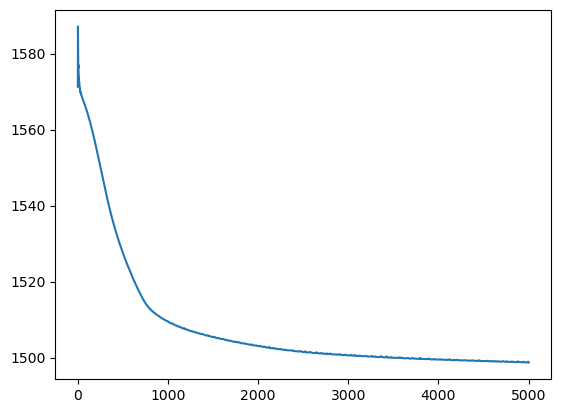

In [21]:
sca_losses = fit_data_sca['losses'].detach().numpy()
plt.plot(sca_losses)

## Plot Result

In [22]:
# define some colors
# red/green corresponds to backward and forward conditions.
# dark/light colors correspond to top-start vs. bottom-start conditions
colors = np.array(['darkgreen','springgreen','maroon','red'])
colors = np.tile(colors,(1,5)).squeeze()

In [25]:
# number of rows
numRows = int(num_components/2)

# range of y axis
yRange = [-2.5,2.5]

fig = make_subplots(rows=numRows,cols = 2,shared_xaxes = True,vertical_spacing = 0)

for i in range(num_components):
    for j in range(numConds):

        # grab the indices for this condition
        # remember that conditions are 1 indexed
        condIdx = condNum_ds == (j+1)

        # subplot indices
        rowIdx = int(np.mod(i,numRows))+1
        colIdx = int(i/numRows)+1


        tempProj = go.Scatter(x = time_ds[condIdx],y = sca_latent[condIdx,i],
                    line = go.scatter.Line(color = colors[j],width = 2),showlegend = False)
        fig.add_trace(tempProj,row = rowIdx,col=colIdx)

    # add a vertical line for scale
    scaleLine = go.Scatter(x = [0,0],y = [-1,1],showlegend = False,mode = 'lines',
                               line = go.scatter.Line(color = 'black',width = 5))
    fig.add_trace(scaleLine,row = rowIdx,col = colIdx)


fig.update_layout(height = 1000,width =1000,title = 'SCA',title_font_color = 'black',
                  paper_bgcolor = 'white',
                  plot_bgcolor = 'white')
fig.update_yaxes(showgrid = False,zeroline = False,visible = False, range=yRange)
fig.update_xaxes(color = 'black',showgrid = False,zeroline = False,visible = False)
fig.update_xaxes(color = 'black',showgrid = False,zeroline = False,
                 ticks = 'outside',tickvals = [tgt_idx,move_idx],ticktext = ['target','move'],visible = True,row = numRows,col = 1)

## Fitting WPCA

In [28]:
W_ = create_W(torch.tensor(data_final)).numpy()
W_full = create_W(torch.tensor(data_final)).numpy()
svd = TruncatedSVD(num_components)
svd.fit(W_@data_final)
U = svd.components_.T
V = svd.components_

pca_latent = data_final@U
out_wpca = pca_latent@V

In [29]:
# number of rows
numRows = int(num_components/2)

# range of y axis
yRange = [-2.5,2.5]

fig = make_subplots(rows=numRows,cols = 2,shared_xaxes = True,vertical_spacing = 0)

for i in range(num_components):
    for j in range(numConds):

        # grab the indices for this condition
        # remember that conditions are 1 indexed
        condIdx = condNum_ds == (j+1)

        # subplot indices
        rowIdx = int(np.mod(i,numRows))+1
        colIdx = int(i/numRows)+1


        tempProj = go.Scatter(x = time_ds[condIdx],y = pca_latent[condIdx,i],
                    line = go.scatter.Line(color = colors[j],width = 2),showlegend = False)
        fig.add_trace(tempProj,row = rowIdx,col=colIdx)

    # add a vertical line for scale
    scaleLine = go.Scatter(x = [0,0],y = [-1,1],showlegend = False,mode = 'lines',
                               line = go.scatter.Line(color = 'black',width = 5))
    fig.add_trace(scaleLine,row = rowIdx,col = colIdx)


fig.update_layout(height = 1000,width =1000,title = 'weighted PCA',title_font_color = 'black',
                  paper_bgcolor = 'white',
                  plot_bgcolor = 'white')
fig.update_yaxes(showgrid = False,zeroline = False,visible = False, range=yRange)
fig.update_xaxes(color = 'black',showgrid = False,zeroline = False,visible = False)
fig.update_xaxes(color = 'black',showgrid = False,zeroline = False,
                 ticks = 'outside',tickvals = [tgt_idx,move_idx],ticktext = ['target','move'],visible = True,row = numRows,col = 1)
